# LSTM Deep Learning Model

## Business Objective

The objective of this notebook is to develop a Long Short-Term Memory (LSTM) neural network for forecasting burger sales using historical sales patterns, weather variables, and engineered time-based features.

Unlike traditional machine learning algorithms, LSTMs can learn temporal dependencies by processing sequential observations, making them well suited for time-series forecasting.

The model developed in this notebook will later be compared with the LightGBM model to determine which approach provides better forecasting performance.

In [1]:
# ==========================================================
# LSTM Deep Learning Model
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

plt.style.use("ggplot")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# ==========================================================
# Project Paths
# ==========================================================

from pathlib import Path

# Project root folder
PROJECT_ROOT = Path.cwd().parent

# Frequently used directories
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)

Project Root : c:\Users\pc\Desktop\Burger_Sales_Forecasting
Data Folder  : c:\Users\pc\Desktop\Burger_Sales_Forecasting\data


In [3]:
# ==========================================================
# Load Prepared Sequences
# ==========================================================

X_train = np.load(DATA_DIR / "X_train_seq.npy")
X_validation = np.load(DATA_DIR / "X_validation_seq.npy")
X_test = np.load(DATA_DIR / "X_test_seq.npy")

y_train = np.load(DATA_DIR / "y_train_seq.npy")
y_validation = np.load(DATA_DIR / "y_validation_seq.npy")
y_test = np.load(DATA_DIR / "y_test_seq.npy")

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (17065, 30, 19)
Validation: (3633, 30, 19)
Testing: (3634, 30, 19)


In [4]:
# ==========================================================
# Build LSTM Model
# ==========================================================

model = Sequential()

# ----------------------------------------------------------
# First LSTM Layer
# ----------------------------------------------------------
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(30, 19)
    )
)

# Prevent overfitting
model.add(Dropout(0.20))

# ----------------------------------------------------------
# Second LSTM Layer
# ----------------------------------------------------------
model.add(
    LSTM(
        units=32
    )
)

# Prevent overfitting
model.add(Dropout(0.20))

# ----------------------------------------------------------
# Dense Hidden Layer
# ----------------------------------------------------------
model.add(
    Dense(
        units=16,
        activation="relu"
    )
)

# ----------------------------------------------------------
# Output Layer
# ----------------------------------------------------------
model.add(
    Dense(1)
)

model.summary()

c:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,465 (134.63 KB)

 Non-trainable params: 0 (0.00 B)

# Building the LSTM Architecture

The LSTM neural network is designed to learn temporal patterns from historical observations.

The architecture consists of:

- **First LSTM Layer (64 units):** Learns high-level temporal patterns from the previous 30 days.
- **Dropout Layer (20%):** Reduces overfitting by randomly disabling neurons during training.
- **Second LSTM Layer (32 units):** Learns more refined sequential relationships from the first LSTM layer.
- **Second Dropout Layer (20%):** Further improves the model's ability to generalize.
- **Dense Hidden Layer (16 neurons):** Combines the extracted features before making the final prediction.
- **Output Layer (1 neuron):** Predicts the burger sales for the next day.

The architecture is intentionally kept relatively simple because the dataset is moderate in size. A deeper network could increase the risk of overfitting without providing significant performance improvements.

In [5]:
# ==========================================================
# Compile Model
# ==========================================================

model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [6]:
# ==========================================================
# Training Callbacks
# ==========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True
)

checkpoint = ModelCheckpoint(

    "../models/best_lstm.keras",

    monitor="val_loss",

    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1
)

# Model Training

The LSTM model is trained using the training dataset while monitoring its performance on the validation dataset.

Three callbacks are used during training:

- **EarlyStopping** prevents unnecessary training once validation performance stops improving.
- **ModelCheckpoint** saves the best-performing model during training.
- **ReduceLROnPlateau** automatically lowers the learning rate when the validation loss stops improving.

These techniques improve model generalization and reduce the likelihood of overfitting.

In [7]:
# ==========================================================
# Train the LSTM Model
# ==========================================================

# Ensure model is compiled before training (prevents ValueError)
if not hasattr(model, "optimizer") or model.optimizer is None:
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_validation,
        y_validation
    ),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],

    verbose=1
)

print("Training Complete!")

Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 4386644.0000 - mae: 1794.1244 - val_loss: 3776054.0000 - val_mae: 1633.8243 - learning_rate: 0.0010
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 3229477.5000 - mae: 1500.4473 - val_loss: 2458734.0000 - val_mae: 1301.5973 - learning_rate: 0.0010
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 2012404.3750 - mae: 1201.2743 - val_loss: 1514351.2500 - val_mae: 1065.0889 - learning_rate: 0.0010
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 1374037.3750 - mae: 1035.8002 - val_loss: 1204545.0000 - val_mae: 978.2899 - learning_rate: 0.0010
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - loss: 1219080.0000 - mae: 985.1177 - val_loss: 1165643.8750 - val_mae: 962.7062 - learning_rate: 0.0010
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 1203758.0000 - mae: 976.7336 - val_loss: 1165118.1250 - val_mae: 960.9183 - learning_rate: 0.0010
Epoch 7/100
534/534 ━━━━━━━

# Training Results

The LSTM model was trained using the Adam optimizer with Mean Squared Error (MSE) as the loss function.

Training was monitored using validation loss to detect overfitting.

Several callbacks were employed:

- **EarlyStopping** restored the best-performing model after validation performance stopped improving.
- **ReduceLROnPlateau** reduced the learning rate when the validation loss plateaued.
- **ModelCheckpoint** automatically saved the best-performing model during training.

These techniques improve training stability and help the model generalize to unseen data.

# Learning Curves

Learning curves show how the model's loss changed during training.

By comparing the training and validation loss, we can determine whether the model is:

- Learning effectively,
- Overfitting,
- Underfitting, or
- Converging appropriately.

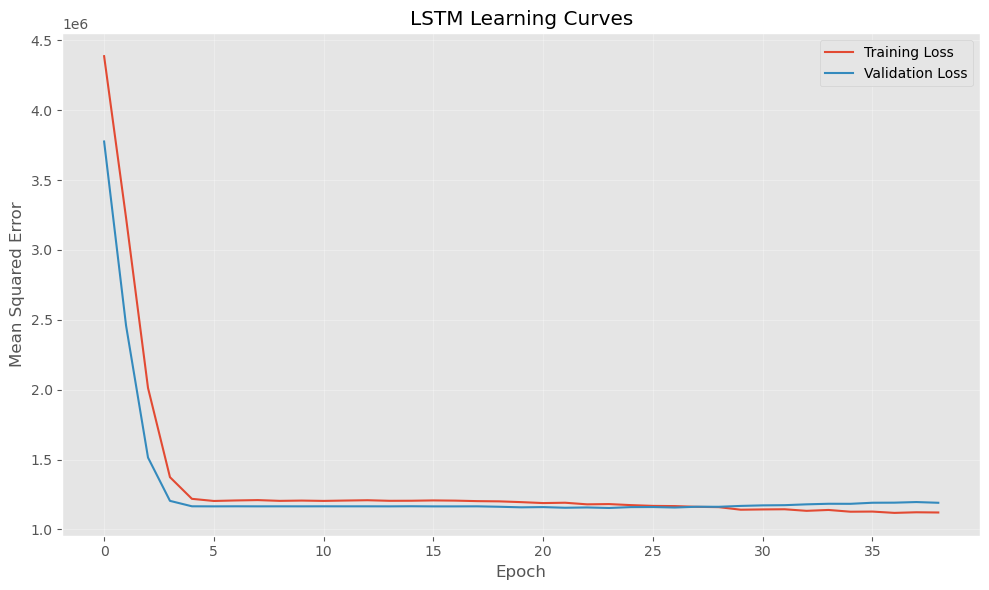

In [8]:
# ==========================================================
# Plot Learning Curves
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Learning Curves")

plt.xlabel("Epoch")

plt.ylabel("Mean Squared Error")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lstm_learning_curves.png",
    dpi=300
)

plt.show()

# Model Predictions

The trained LSTM model is used to generate predictions for the training, validation, and testing datasets.

These predictions are then evaluated using multiple regression metrics.

In [9]:
# ==========================================================
# Generate Predictions
# ==========================================================

train_predictions = model.predict(X_train)

validation_predictions = model.predict(X_validation)

test_predictions = model.predict(X_test)

print("Predictions Generated Successfully!")

534/534 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Predictions Generated Successfully!


In [10]:
# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(actual, predicted, dataset_name):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    smape = (
        np.mean(
            2 * np.abs(predicted.flatten() - actual) /
            (
                np.abs(actual) +
                np.abs(predicted.flatten())
            )
        )
    ) * 100

    print("=" * 50)
    print(dataset_name)
    print("=" * 50)

    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"R²    : {r2:.4f}")
    print(f"SMAPE : {smape:.2f}%")

In [11]:
evaluate_model(
    y_train,
    train_predictions,
    "Training"
)

evaluate_model(
    y_validation,
    validation_predictions,
    "Validation"
)

evaluate_model(
    y_test,
    test_predictions,
    "Testing"
)

Training
MAE   : 952.59
RMSE  : 1069.40
R²    : 0.0313
SMAPE : 60.55%
Validation
MAE   : 954.87
RMSE  : 1074.07
R²    : 0.0097
SMAPE : 60.89%
Testing
MAE   : 960.45
RMSE  : 1080.06
R²    : 0.0165
SMAPE : 61.93%


In [12]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nFirst target values:")
print(y_train[:10])

X_train: (17065, 30, 19)
y_train: (17065,)

First target values:
[2862.05  621.04 2985.29 1388.21  453.66  486.53 2805.5  2462.21 2598.35
 2236.54]


In [13]:
print("Sequence length:", X_train.shape[1])
print("Number of features:", X_train.shape[2])

print("\nFirst timestep of first sequence:")
print(X_train[0][0])

Sequence length: 30
Number of features: 19

First timestep of first sequence:
[-0.68159434  0.31608948 -1.25715336  1.69593905  0.72707914  0.0238676
 -5.19933758 -5.19933758 -1.39451162  0.36821529 -5.19933758 -5.19933758
 -5.19933758 -1.48771987 -0.80531818 -0.26477411 -0.7156657  -1.3290051
  1.10001297]


In [14]:
print("Minimum Sales:", y_train.min())
print("Maximum Sales:", y_train.max())
print("Mean Sales:", y_train.mean())

Minimum Sales: 0.26
Maximum Sales: 3564.54
Mean Sales: 1885.1326492821565


# Actual vs Predicted Sales

This visualization compares the actual burger sales with the values predicted by the LSTM model.

If the model performs well, the predicted values should closely follow the actual sales. Large deviations indicate prediction errors and may suggest underfitting or overfitting.

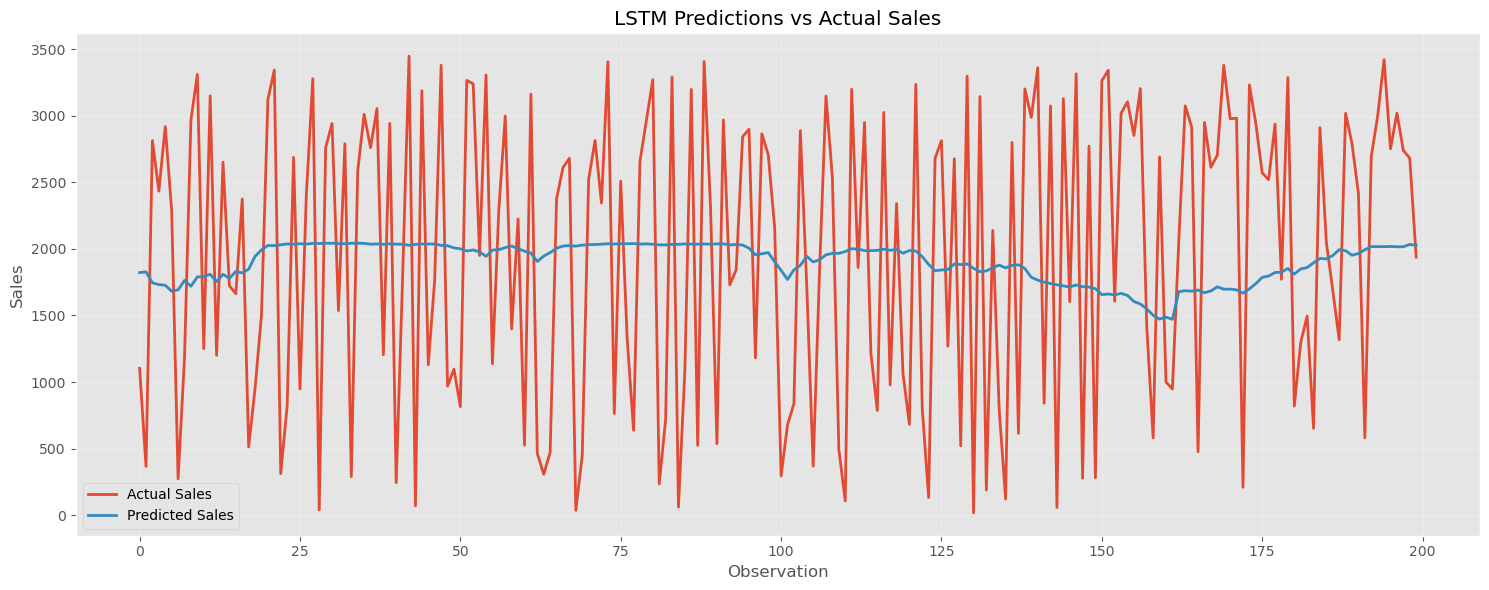

In [15]:
# ==========================================================
# Actual vs Predicted Sales
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test[:200],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    test_predictions[:200],
    label="Predicted Sales",
    linewidth=2
)

plt.title("LSTM Predictions vs Actual Sales")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lstm_predictions.png",
    dpi=300
)

plt.show()

# Predicted vs Actual Scatter Plot

The scatter plot compares predicted sales against the observed sales.

A perfect regression model would produce points lying exactly on the diagonal reference line.

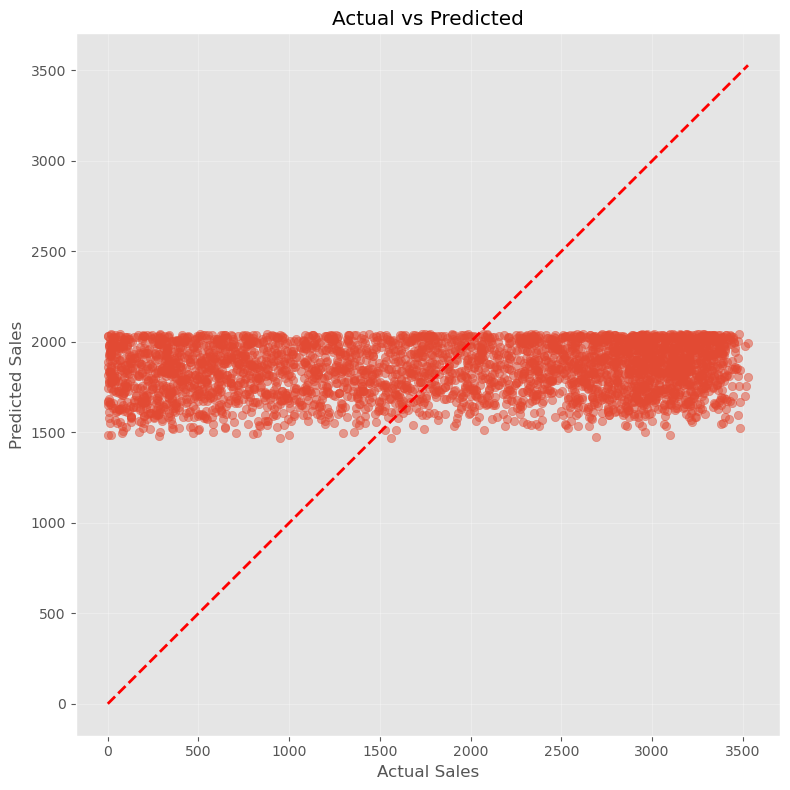

In [16]:
# ==========================================================
# Scatter Plot
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lstm_scatter.png",
    dpi=300
)

plt.show()

# Residual Analysis

Residuals represent the difference between the actual sales and the predicted sales.

A well-performing regression model should produce residuals that are randomly distributed around zero without any obvious patterns.

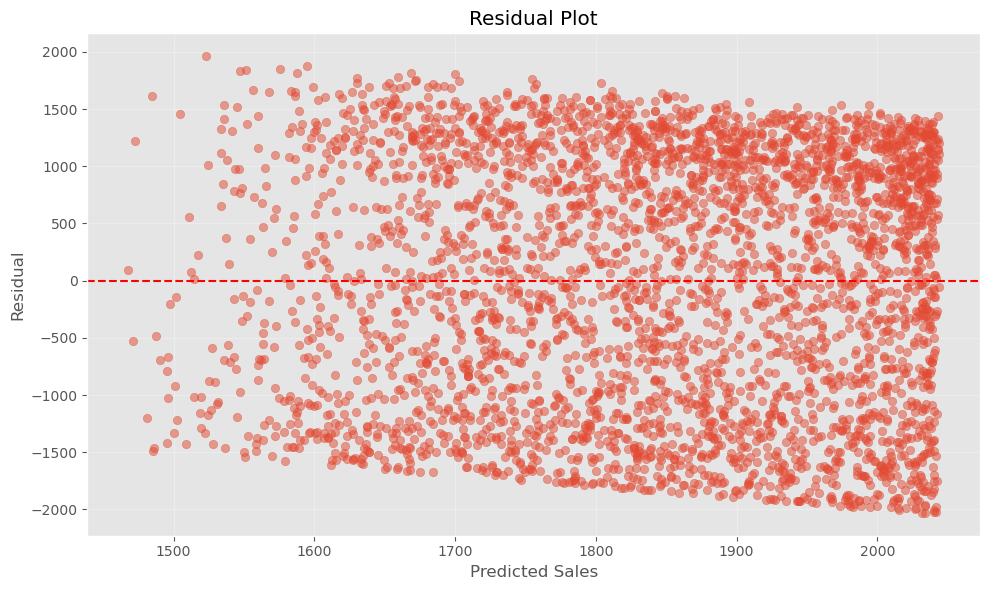

In [17]:
# ==========================================================
# Residual Plot
# ==========================================================

residuals = y_test - test_predictions.flatten()

plt.figure(figsize=(10,6))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lstm_residuals.png",
    dpi=300
)

plt.show()

# Residual Distribution

The distribution of residuals provides additional insight into the prediction errors.

Ideally, the residuals should be centered around zero and approximately symmetric.

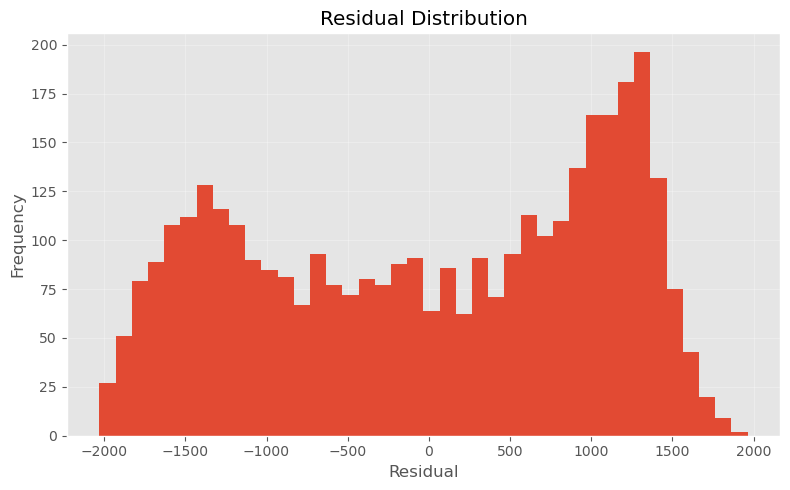

In [18]:
# ==========================================================
# Residual Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=40
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/lstm_error_distribution.png",
    dpi=300
)

plt.show()

In [19]:
# ==========================================================
# Save Model
# ==========================================================

model.save("../models/lstm_experiment1.keras")

print("Model saved successfully!")

Model saved successfully!


# Conclusions

The first LSTM experiment successfully demonstrated the implementation of a recurrent neural network for burger sales forecasting.

Although the model converged during training, its predictive performance was considerably lower than the LightGBM baseline.

Possible reasons include:

- The preprocessing pipeline was originally designed for a tree-based model.
- The target variable was not scaled prior to training.
- The LSTM architecture may require further tuning.
- The engineered lag features favor tree-based algorithms more than recurrent neural networks.

These findings motivate a second experiment using a preprocessing pipeline specifically designed for deep learning.